# Milestone 3 — Forecasting Model Development & Optimization
**Project:** Walmart Sales Forecasting

Goal: build and compare a few forecasting approaches, then pick the best one based on RMSE / MAE / MAPE.

**Models compared:**
1. Naive baseline (persistence + seasonal naive)
2. Facebook Prophet (one model per store)
3. XGBoost (one global model using Store + time + lag features), tuned with `TimeSeriesSplit`

**Important:** since this is time-series data, I use a **time-based train/test split** (last 12 weeks as test) instead of a random split — a random split would leak future information into training and give misleadingly good results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from prophet import Prophet
import mlflow
import joblib
import logging

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load data and build lag features

From Milestone 1/2 I know `Store` and seasonality matter most. I'll add lag-based features per store (previous week, same week last year, and a 4-week rolling average) — these are very predictive for retail sales and are common features for this kind of problem.

In [2]:
df = pd.read_csv('../data/processed/walmart_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# lag features per store - shift(1) first to avoid leaking the current week into rolling/lag values
df['lag_1'] = df.groupby('Store')['Weekly_Sales'].transform(lambda s: s.shift(1))
df['lag_52'] = df.groupby('Store')['Weekly_Sales'].transform(lambda s: s.shift(52))
df['rolling_mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda s: s.shift(1).rolling(4).mean())

df[['Store', 'Date', 'Weekly_Sales', 'lag_1', 'lag_52', 'rolling_mean_4']].head(8)

,Store,Date,Weekly_Sales,lag_1,lag_52,rolling_mean_4
0,1,2010-02-05,1643690.90,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1643690.90,NaN,NaN
2,1,2010-02-19,1611968.17,1641957.44,NaN,NaN
3,1,2010-02-26,1409727.59,1611968.17,NaN,NaN
4,1,2010-03-05,1554806.68,1409727.59,NaN,1.576836e+06
5,1,2010-03-12,1439541.59,1554806.68,NaN,1.554615e+06
6,1,2010-03-19,1472515.79,1439541.59,NaN,1.504011e+06
7,1,2010-03-26,1404429.92,1472515.79,NaN,1.469148e+06


`lag_52` needs a full year of history before it has a value, so the first ~52 weeks of each store will have missing lag features. I'll drop those rows — this does cost some training data, but using a feature with lots of missing values would hurt the model more than losing the first year.

Note: I'm dropping the `Day_of_Week` feature entirely — I checked in Milestone 1 and every record falls on a Friday (since this is weekly data), so it has zero variance and gives the model nothing to learn from.

In [3]:
model_df = df.dropna(subset=['lag_1', 'lag_52', 'rolling_mean_4']).reset_index(drop=True)
print(f'Rows before dropping: {len(df)}, after: {len(model_df)}')

Rows before dropping: 6435, after: 4095


## 2. Time-based train/test split

Using the last 12 weeks as the test set, for every store. This mimics a real forecasting scenario — predicting the near future based on everything we know up to today.

In [4]:
cutoff_date = model_df['Date'].max() - pd.Timedelta(weeks=12)

train = model_df[model_df['Date'] <= cutoff_date].copy()
test = model_df[model_df['Date'] > cutoff_date].copy()

print('Cutoff date:', cutoff_date.date())
print(f'Train: {len(train)} rows ({train["Date"].min().date()} to {train["Date"].max().date()})')
print(f'Test:  {len(test)} rows ({test["Date"].min().date()} to {test["Date"].max().date()})')
print('Stores covered in test set:', test['Store'].nunique())

Cutoff date: 2012-08-03
Train: 3555 rows (2011-02-04 to 2012-08-03)
Test:  540 rows (2012-08-10 to 2012-10-26)
Stores covered in test set: 45


In [5]:
def evaluate(y_true, y_pred, name):
    """Compute RMSE, MAE and MAPE and return them as a dict."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:<25} RMSE={rmse:>10,.0f}  MAE={mae:>10,.0f}  MAPE={mape:.2f}%')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

results = []

## 3. Baseline models

Before trying anything fancy, I want a simple baseline to know what "good" looks like. If a complex model can't beat a naive guess, it's not worth using.

In [6]:
# Baseline 1: naive persistence — predict this week's sales = last week's sales
results.append(evaluate(test['Weekly_Sales'], test['lag_1'], 'Naive (last week)'))

# Baseline 2: seasonal naive — predict this week's sales = same week last year
results.append(evaluate(test['Weekly_Sales'], test['lag_52'], 'Seasonal Naive (last year)'))

Naive (last week)         RMSE=    72,442  MAE=    46,966  MAPE=4.71%
Seasonal Naive (last year) RMSE=    85,366  MAE=    53,769  MAPE=5.46%


Both baselines land around 4.7-5.5% MAPE. The seasonal naive is actually slightly *worse* than just using last week's value — makes sense, since week-to-week sales are more stable than year-over-year for the same store.

## 4. XGBoost (global model, tuned)

One single model trained across all stores, using `Store` as a categorical feature alongside time and lag features. I used `GridSearchCV` with `TimeSeriesSplit` (instead of regular k-fold) so that validation folds never look at data from the future relative to the training fold.

In [7]:
features = ['Store', 'Month', 'Week', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
            'CPI', 'Unemployment', 'lag_1', 'lag_52', 'rolling_mean_4']
target = 'Weekly_Sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_grid = GridSearchCV(xgb_base, param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print('Best hyperparameters:', xgb_grid.best_params_)
xgb_model = xgb_grid.best_estimator_

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [8]:
xgb_preds = xgb_model.predict(X_test)
results.append(evaluate(y_test, xgb_preds, 'XGBoost (tuned)'))

XGBoost (tuned)           RMSE=    61,216  MAE=    40,735  MAPE=4.20%


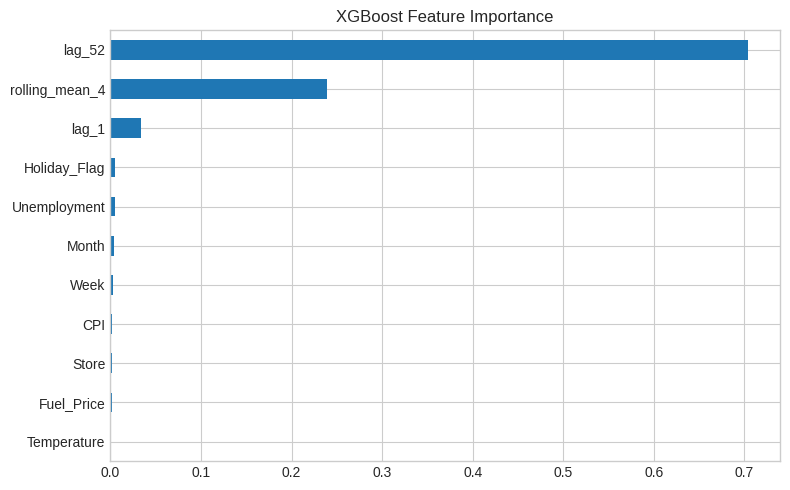

In [9]:
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('../reports/figures/08_feature_importance.png', dpi=110)
plt.show()

As expected, `lag_52` (same week last year) and `rolling_mean_4` dominate — the model is mostly leaning on recent history and last year's seasonal pattern, which fits what I found in the EDA: store-level seasonality is the main driver, while CPI/Fuel Price/Temperature/Store contribute very little once lag features are available.

## 5. Prophet (per-store models)

Prophet models trend + yearly seasonality automatically, so it's a good fit here. Since each store has its own scale and pattern, I train **one Prophet model per store** (45 in total) and pool all the test predictions together to get an overall score comparable to XGBoost.

In [10]:
prophet_actual = []
prophet_pred = []

for store_id in sorted(df['Store'].unique()):
    store_df = df[df['Store'] == store_id][['Date', 'Weekly_Sales', 'Holiday_Flag']].copy()
    store_df.columns = ['ds', 'y', 'holiday_flag']

    store_train = store_df[store_df['ds'] <= cutoff_date]
    store_test = store_df[store_df['ds'] > cutoff_date]

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.add_regressor('holiday_flag')
    m.fit(store_train)

    forecast = m.predict(store_test[['ds', 'holiday_flag']])

    prophet_actual.extend(store_test['y'].values)
    prophet_pred.extend(forecast['yhat'].values)

prophet_actual = np.array(prophet_actual)
prophet_pred = np.array(prophet_pred)
results.append(evaluate(prophet_actual, prophet_pred, 'Prophet (per-store)'))

01:42:34 - cmdstanpy - INFO - Chain [1] start processing


01:42:34 - cmdstanpy - INFO - Chain [1] done processing


01:42:34 - cmdstanpy - INFO - Chain [1] start processing


01:42:34 - cmdstanpy - INFO - Chain [1] done processing


01:42:34 - cmdstanpy - INFO - Chain [1] start processing


...

01:42:37 - cmdstanpy - INFO - Chain [1] start processing


01:42:37 - cmdstanpy - INFO - Chain [1] done processing


01:42:37 - cmdstanpy - INFO - Chain [1] start processing


01:42:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet (per-store)       RMSE=    61,954  MAE=    42,730  MAPE=4.42%


## 6. Model comparison

In [11]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,MAPE
0,XGBoost (tuned),61216.458734,40735.111494,4.197141
1,Prophet (per-store),61954.220845,42729.995010,4.420113
2,Naive (last week),72442.052298,46965.548463,4.709854
3,Seasonal Naive (last year),85365.673831,53768.951037,5.457812


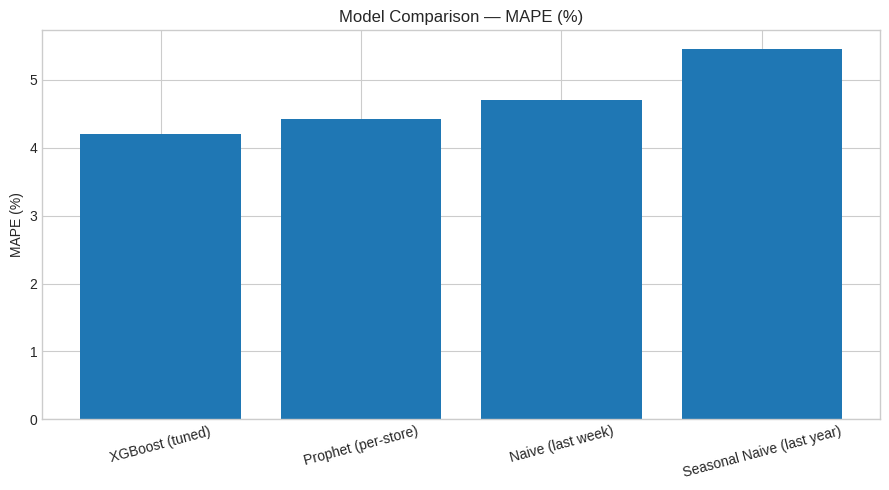

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_df['Model'], results_df['MAPE'], color='#1f77b4')
ax.set_title('Model Comparison — MAPE (%)')
ax.set_ylabel('MAPE (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/09_model_comparison.png', dpi=110)
plt.show()

**XGBoost is the best model** on all three metrics, with Prophet close behind, and both clearly beat the naive baselines. This makes sense — XGBoost can combine the lag/seasonal information that Prophet captures *and* the store-level differences that Prophet (fit separately per store) can't share across stores.

I'm going with **XGBoost as the final model**.

## 7. Track experiments with MLflow

Logging each model run (parameters + metrics) so the experiments are reproducible and comparable later.

In [13]:
mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('walmart-sales-forecasting')

for _, row in results_df.iterrows():
    with mlflow.start_run(run_name=row['Model']):
        mlflow.log_param('model_type', row['Model'])
        mlflow.log_metric('RMSE', row['RMSE'])
        mlflow.log_metric('MAE', row['MAE'])
        mlflow.log_metric('MAPE', row['MAPE'])

# log the winning XGBoost model with its tuned hyperparameters
with mlflow.start_run(run_name='XGBoost_final'):
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('RMSE', results_df.loc[results_df['Model']=='XGBoost (tuned)', 'RMSE'].values[0])
    mlflow.log_metric('MAE', results_df.loc[results_df['Model']=='XGBoost (tuned)', 'MAE'].values[0])
    mlflow.log_metric('MAPE', results_df.loc[results_df['Model']=='XGBoost (tuned)', 'MAPE'].values[0])
    mlflow.xgboost.log_model(xgb_model, 'model')

print('All runs logged. Run `mlflow ui --backend-store-uri sqlite:///mlflow.db` from the project root to view them.')

2026/06/28 01:42:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/28 01:42:38 INFO mlflow.store.db.utils: Updating database tables


2026/06/28 01:42:39 INFO mlflow.tracking.fluent: Experiment with name 'walmart-sales-forecasting' does not exist. Creating a new experiment.


2026/06/28 01:42:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


All runs logged. Run `mlflow ui --backend-store-uri sqlite:///mlflow.db` from the project root to view them.


## 8. Save the final model

Saving the trained XGBoost model + the list of features it expects, so the Streamlit app can load it directly.

In [14]:
joblib.dump(xgb_model, '../models/xgb_sales_model.pkl')
joblib.dump(features, '../models/model_features.pkl')

print('Model and feature list saved to ../models/')

Model and feature list saved to ../models/


## Summary of findings

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| Naive (last week) | ~72K | ~47K | 4.71% |
| Seasonal Naive (last year) | ~85K | ~54K | 5.46% |
| Prophet (per-store) | ~62K | ~43K | 4.42% |
| **XGBoost (tuned)** | **~61K** | **~41K** | **4.20%** |

- Both baselines are beaten by the more sophisticated models, which justifies using ML instead of a naive guess.
- **XGBoost** wins overall — it's selected as the final model.
- The most important features are `lag_52` (same week last year) and `rolling_mean_4` (recent trend), confirming the seasonality finding from Milestone 1/2.
- The final model and feature list are saved in `../models/` for the Streamlit app, and all experiment runs are tracked in MLflow.

**Next step (Milestone 4):** deploy this model in a Streamlit app and document the MLOps setup.